# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [1]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 5.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: spacy
    Found existing installation: spacy 3.7.4
    Uninstalling spacy-3.7.4:
      Successfully uninstalled spacy-3.7.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 2.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.20.1
    Uninstalling pydantic_core-2.20.1:
      Successfully uninstalled pydantic_core-2.20.1
  Attempting uninstall: pydantic
    Found existing installat

## Importing the necessary libraries

In [2]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [65]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [62]:
# Import the first file - True.csv
df_fake_raw = pd.read_csv("/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C5/Assignment/Starter Notebook + Data/Fake.csv")

# Import the second file - Fake.csv
df_true_raw = pd.read_csv("/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C5/Assignment/Starter Notebook + Data/True.csv")


## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [66]:
# Inspect the DataFrame with True News to understand the given data
df_true_wc = df_true_raw.copy()
df_true_wc.head()


title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [67]:
# Inspect the DataFrame with Fake News to understand the given data
df_fake_wc = df_fake_raw.copy()
df_fake_wc.head()

,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.","December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former

In [68]:
# Print the column details for True News DataFrame
df_true_wc.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


In [69]:
# Print the column details for Fake News Dataframe
df_fake_wc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


In [76]:
# Print the column names of both DataFrames
print("Fake News Columns:", df_fake_wc.columns)
print("True News Columns:",df_true_wc.columns)

Fake News Columns: Index(['title', 'text', 'date'], dtype='object')
True News Columns: Index(['title', 'text', 'date'], dtype='object')


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [77]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
df_true_wc['news_label'] = 1
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
df_fake_wc['news_label'] = 0

### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [79]:
# Combine the true and fake news DataFrames into a single DataFrame
df_comb = pd.concat([df_true_wc, df_fake_wc])

In [82]:
# Display the first 5 rows of the combined DataFrame to verify the result
df_comb.head(5)


title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [83]:
# Check Presence of Null Values
df_comb.isnull().sum()

title         21
text          21
date          42
news_label     0
dtype: int64

In [85]:
# Handle Rows with Null Values
df_comb = df_comb.dropna()
df_comb.isnull().sum()


title         0
text          0
date          0
news_label    0
dtype: int64

### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [86]:
df_comb.head(5)

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [89]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space

df_comb['news_text'] = df_comb['title'] + ' ' + df_comb['text']

# Drop the irrelevant columns from the DataFrame as they are no longer needed
df_comb = df_comb.drop(['title', 'text'], axis=1)

# Display the first 5 rows of the updated DataFrame to check the result
df_comb.head()


date  news_label  \
0  December 31, 2017            1   
1  December 29, 2017            1   
2  December 31, 2017            1   
3  December 30, 2017            1   
4  December 29, 2017            1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [93]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed

def lemmatize_text(text):
    # Process the text with spaCy
    doc = nlp(str(text))
    # Extract lemmatized tokens
    lemmatized_tokens = [token.lemma_.lower() for token in doc
                        if not token.is_space and not token.is_punct and token.lemma_ != '-PRON-']
    # Join tokens back into a string
    return ' '.join(lemmatized_tokens)

df_comb['news_text_lemmatized'] = df_comb['news_text'].apply(lemmatize_text)
df_comb.head()
# Add 'news_label' column to the new dataframe for topic identification
df_clean = df_comb.copy()
df_clean.head()

date  news_label  \
0  December 31, 2017            1   
1  December 29, 2017            1   
2  December 31, 2017            1   
3  December 30, 2017            1   
4  December 29, 2017            1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [94]:
# Write the function here to clean the text and remove all the unnecessary elements

def clean_text_enhanced(text):
    
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to lower case
    text = str(text).lower()
    
    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove URLs, email addresses
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove words with numbers
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    
    # Remove extra whitespaces and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text





#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [95]:
# Apply the function to clean the news text and remove all unnecessary element

# Store it in a separate column in the new DataFrame
df_clean['news_text_lemmatized_cleaned'] = df_clean['news_text_lemmatized'].apply(clean_text_enhanced)




### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [96]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags


def pos_tag_and_lemmatize_spacy(text):

    if pd.isna(text) or text == '':
        return ''
    
    # Process text with spaCy
    doc = nlp(str(text))
    
    # Filter for nouns (NOUN tag) and lemmatize
    noun_lemmas = [
        token.lemma_.lower() 
        for token in doc 
        if token.pos_ == 'NOUN'  # spaCy uses 'NOUN' for all noun types
        and not token.is_stop   # Remove stopwords
        and not token.is_punct  # Remove punctuation
        and len(token.lemma_) > 1  # Remove single characters
        and token.lemma_ != '-PRON-'  # Remove pronouns
    ]
    
    return ' '.join(noun_lemmas)



#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [97]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
df_clean['news_text_lemmatized_cleaned_pos_tagged'] = df_clean['news_text_lemmatized_cleaned'].apply(pos_tag_and_lemmatize_spacy)


### Save the Cleaned data as a csv file (Recommended)

In [140]:
df_clean.head(1)

date  news_label  \
0  December 31, 2017            1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [141]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C5/Assignment/Starter Notebook + Data/clean_df.csv", index=False)
df_clean_csv = pd.read_csv("/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C5/Assignment/Starter Notebook + Data/clean_df.csv")
df_clean_new = df_clean_csv[['news_label','news_text_lemmatized_cleaned','news_text_lemmatized_cleaned_pos_tagged']]
df_clean_new.head(1)


news_label  \
0           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [142]:
# Check the first few rows of the DataFrame
df_clean_new.head()

news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [143]:
# Check the dimensions of the DataFrame
df_clean_new.shape


(44898, 3)

In [144]:
# Check the number of non-null entries and data types of each column
df_clean_new.isnull().sum()

news_label                                  0
news_text_lemmatized_cleaned                9
news_text_lemmatized_cleaned_pos_tagged    12
dtype: int64

In [145]:
#removing records with null values 
df_clean_new = df_clean_new.dropna(subset=['news_text_lemmatized_cleaned', 'news_text_lemmatized_cleaned_pos_tagged'])
df_clean_new.isnull().sum()

news_label                                 0
news_text_lemmatized_cleaned               0
news_text_lemmatized_cleaned_pos_tagged    0
dtype: int64

## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [147]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data

from sklearn.model_selection import train_test_split

# Extract features and target
X = df_clean_new['news_text_lemmatized_cleaned_pos_tagged']
y = df_clean_new['news_label']

# Applying the Split - 70% train and 30% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.3,      # 30% for validation
    train_size=0.7,     # 70% for training
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Total size: {len(X)}")

# Checking class distribution for both datasets
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nValidation set class distribution:")
print(y_val.value_counts(normalize=True))


Training set size: 31420 (70.0%)
Validation set size: 13466 (30.0%)
Total size: 44886

Training set class distribution:
news_label
0    0.522852
1    0.477148
Name: proportion, dtype: float64

Validation set class distribution:
news_label
0    0.522872
1    0.477128
Name: proportion, dtype: float64


## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [148]:
# Add a new column to calculate the character length of cleaned news text
df_clean_new['clean_text_length'] = df_clean_new['news_text_lemmatized_cleaned'].str.len()

# Add a new column to calculate the character length of lemmatized news text with POS tags removed

df_clean_new['cleaned_pos_tagged_text_length'] = df_clean_new['news_text_lemmatized_cleaned_pos_tagged'].str.len()

In [149]:
df_clean_new.head(1)

news_label  \
0           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

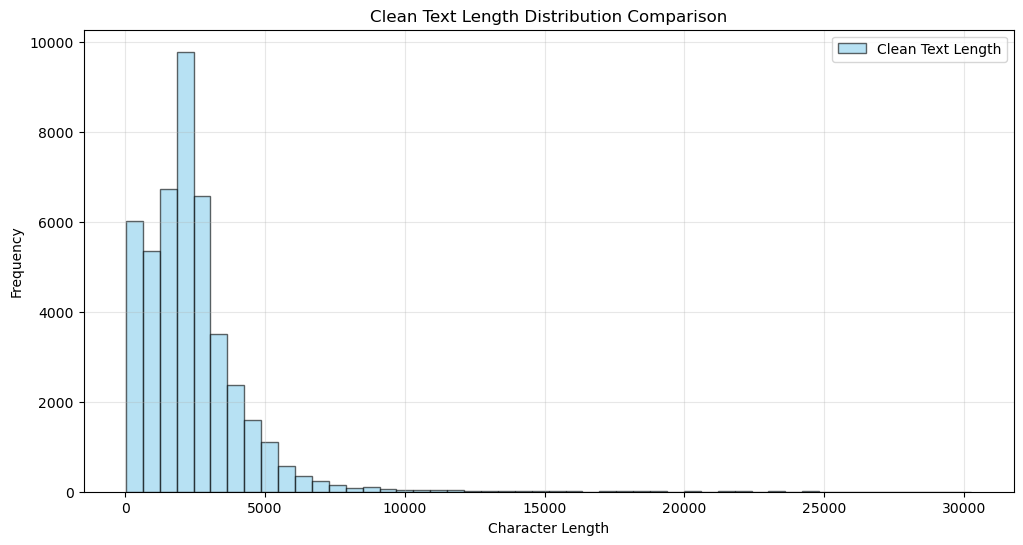

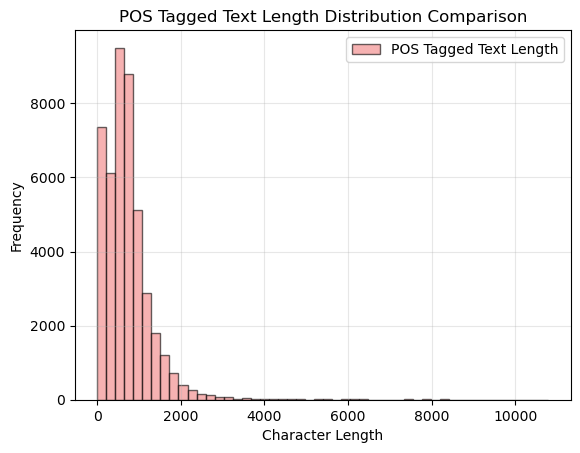

In [151]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed

# Overlapping histograms
plt.figure(figsize=(12, 6))

plt.hist(df_clean_new['clean_text_length'], bins=50, alpha=0.6, 
         label='Clean Text Length', color='skyblue', edgecolor='black')
#plt.hist(df_clean_new['cleaned_pos_tagged_text_length'], bins=50, alpha=0.6, 
#         label='POS Tagged Text Length', color='lightcoral', edgecolor='black')

plt.title('Clean Text Length Distribution Comparison')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.hist(df_clean_new['cleaned_pos_tagged_text_length'], bins=50, alpha=0.6, 
         label='POS Tagged Text Length', color='lightcoral', edgecolor='black')

plt.title('POS Tagged Text Length Distribution Comparison')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

Total true news articles in training: 14992
Combined text length: 11123787 characters


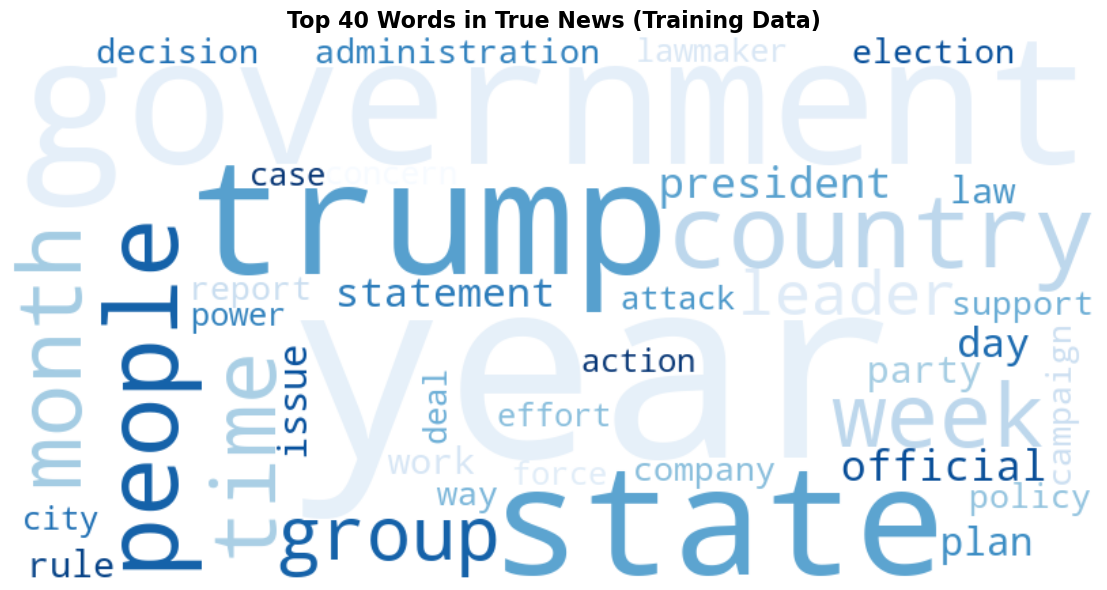

In [152]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Filter news with label 1 (True News) and convert to it string and handle any non-string values

true_news_train = y_train[y_train == 1].index  # Get indices of true news in training set
true_news_text = X_train.loc[true_news_train]  # Get corresponding text

# Convert to string and handle any non-string values
true_news_combined = ' '.join([str(text) for text in true_news_text if pd.notna(text) and str(text).strip() != ''])

print(f"Total true news articles in training: {len(true_news_text)}")
print(f"Combined text length: {len(true_news_combined)} characters")

# Generate word cloud for True News
wordcloud_true = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    max_words=40,  # Top 40 words
    colormap='Blues',
    relative_scaling=0.5,
    random_state=42
).generate(true_news_combined)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in True News (Training Data)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

Total Fake news articles in training: 16428
Combined text length: 11938074 characters


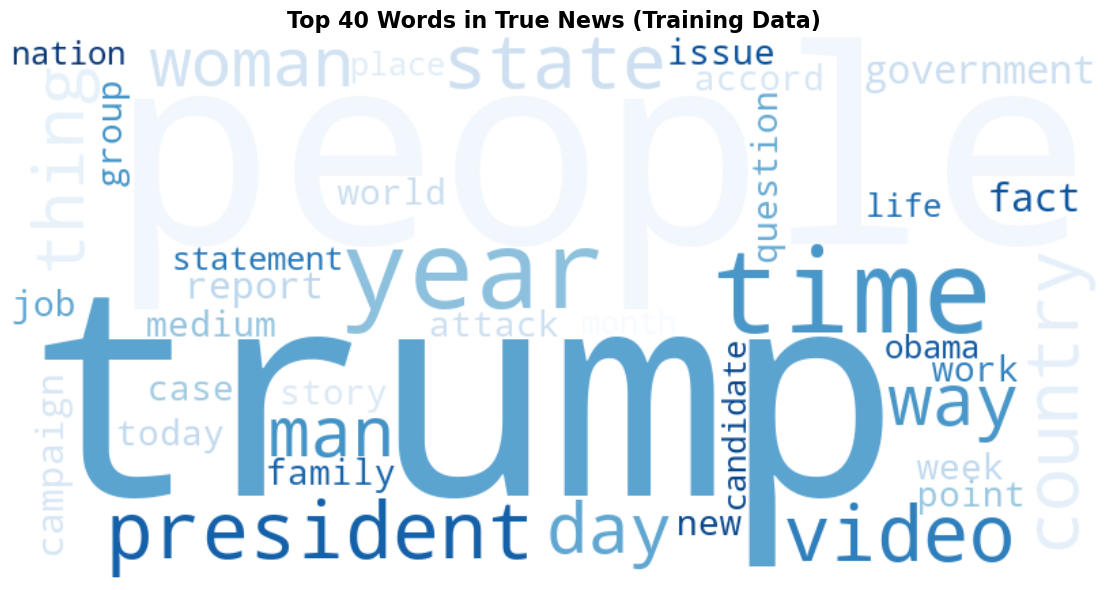

In [155]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values

fake_news_train = y_train[y_train == 0].index  # Get indices of true news in training set

fake_news_text = X_train.loc[fake_news_train]  # Get corresponding text

fake_news_combined = ' '.join([str(text) for text in fake_news_text if pd.notna(text) and str(text).strip() != ''])

print(f"Total Fake news articles in training: {len(fake_news_text)}")
print(f"Combined text length: {len(fake_news_combined)} characters")

# Generate word cloud for True News
wordcloud_true = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    max_words=40,  # Top 40 words
    colormap='Blues',
    relative_scaling=0.5,
    random_state=42
).generate(fake_news_combined)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in True News (Training Data)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [156]:
# Write a function to get the specified top n-grams

from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter


def get_top_ngrams(corpus, n=1, top_k=10, min_df=1, max_df=1.0, stop_words='english'):
    
    # Handle empty or null corpus
    if len(corpus) == 0:
        return []
    
    # Convert to list and filter out empty/null values
    clean_corpus = [str(text) for text in corpus if pd.notna(text) and str(text).strip() != '']
    
    if len(clean_corpus) == 0:
        return []
    
    # Create n-gram vectorizer
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        stop_words=stop_words,
        min_df=min_df,
        max_df=max_df,
        lowercase=True
    )
    
    try:
        # Fit and transform the corpus
        ngram_matrix = vectorizer.fit_transform(clean_corpus)
        
        # Get feature names (n-grams)
        feature_names = vectorizer.get_feature_names_out()
        
        # Sum frequencies across all documents
        frequencies = ngram_matrix.sum(axis=0).A1
        
        # Create list of (n-gram, frequency) tuples
        ngram_freq = list(zip(feature_names, frequencies))
        
        # Sort by frequency in descending order and return top k
        top_ngrams = sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:top_k]
        
        return top_ngrams
    
    except ValueError as e:
        print(f"Error processing n-grams: {e}")
        return []

# Example usage functions for different n-gram types
def get_top_unigrams(corpus, top_k=10, **kwargs):
    #Get top unigrams
    return get_top_ngrams(corpus, n=1, top_k=top_k, **kwargs)

def get_top_bigrams(corpus, top_k=10, **kwargs):
    #Get top bigrams
    return get_top_ngrams(corpus, n=2, top_k=top_k, **kwargs)

def get_top_trigrams(corpus, top_k=10, **kwargs):
    #Get top trigrams
    return get_top_ngrams(corpus, n=3, top_k=top_k, **kwargs)


##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [158]:
# Handle NaN values in the text data
df_clean_new = df_clean_new.dropna(subset=['news_text_lemmatized_cleaned', 'news_text_lemmatized_cleaned_pos_tagged'])
df_clean_new.isnull().sum()


news_label                                 0
news_text_lemmatized_cleaned               0
news_text_lemmatized_cleaned_pos_tagged    0
clean_text_length                          0
cleaned_pos_tagged_text_length             0
dtype: int64

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

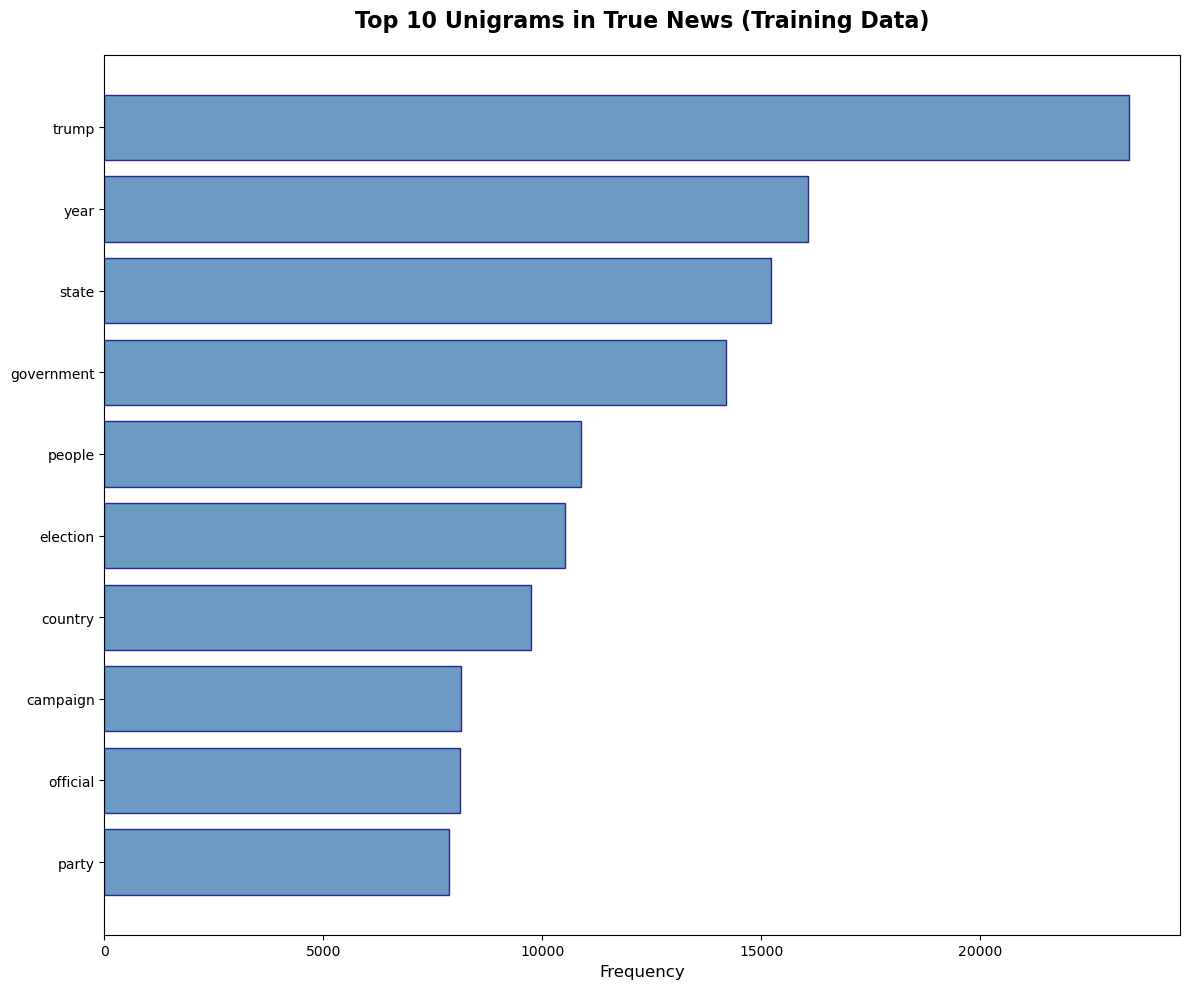

In [163]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
true_unigrams = get_top_ngrams(true_news_text, n=1, top_k=10)

plt.figure(figsize=(12, 10))

ngrams, frequencies = zip(*true_unigrams)

bars = plt.barh(range(len(ngrams)), frequencies, 
                   color='steelblue', edgecolor='navy', alpha=0.8)
    
plt.yticks(range(len(ngrams)), ngrams, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Unigrams in True News (Training Data)', 
            fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



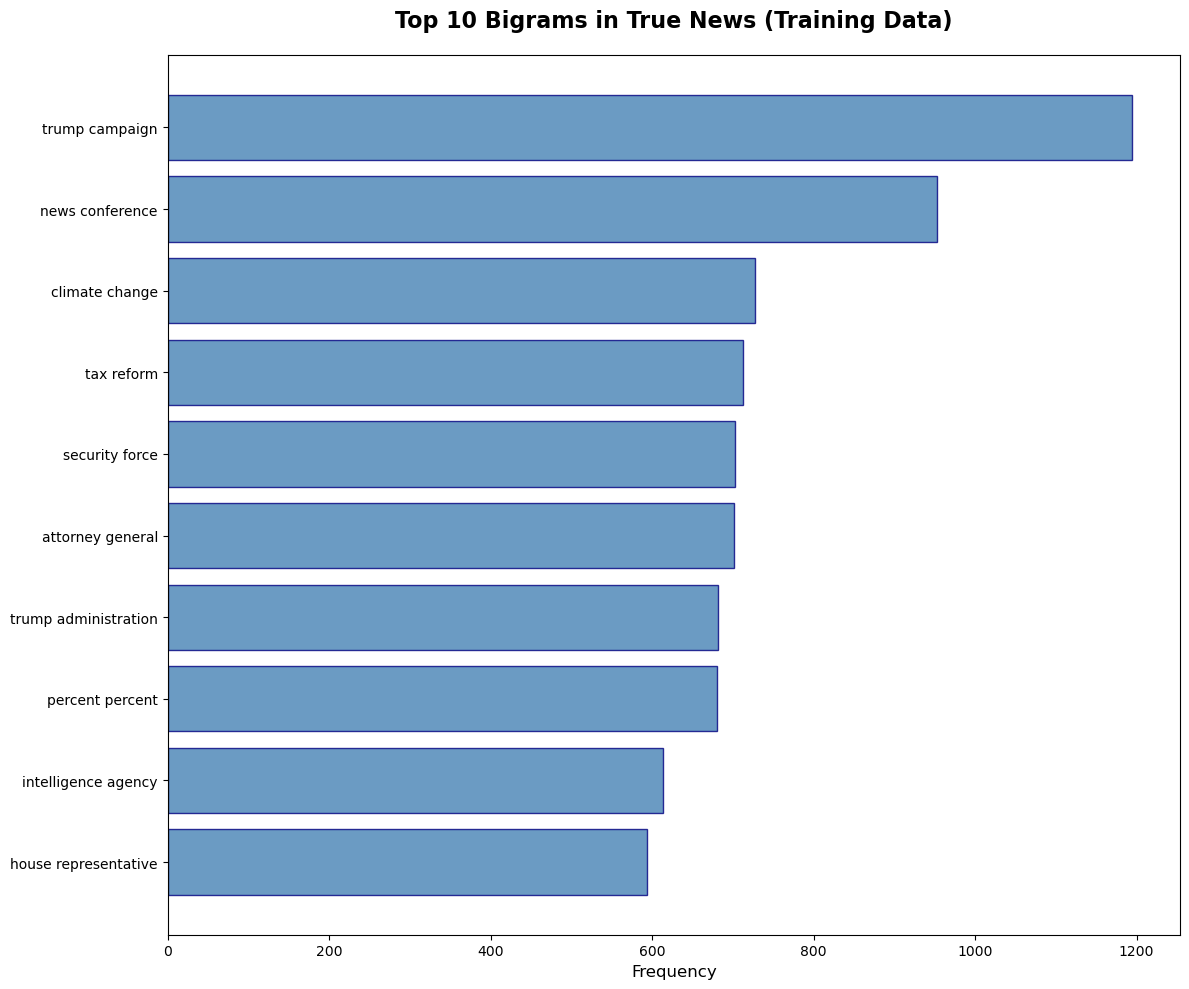

In [164]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
true_unigrams = get_top_ngrams(true_news_text, n=2, top_k=10)

plt.figure(figsize=(12, 10))

ngrams, frequencies = zip(*true_unigrams)

bars = plt.barh(range(len(ngrams)), frequencies, 
                   color='steelblue', edgecolor='navy', alpha=0.8)
    
plt.yticks(range(len(ngrams)), ngrams, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Bigrams in True News (Training Data)', 
            fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



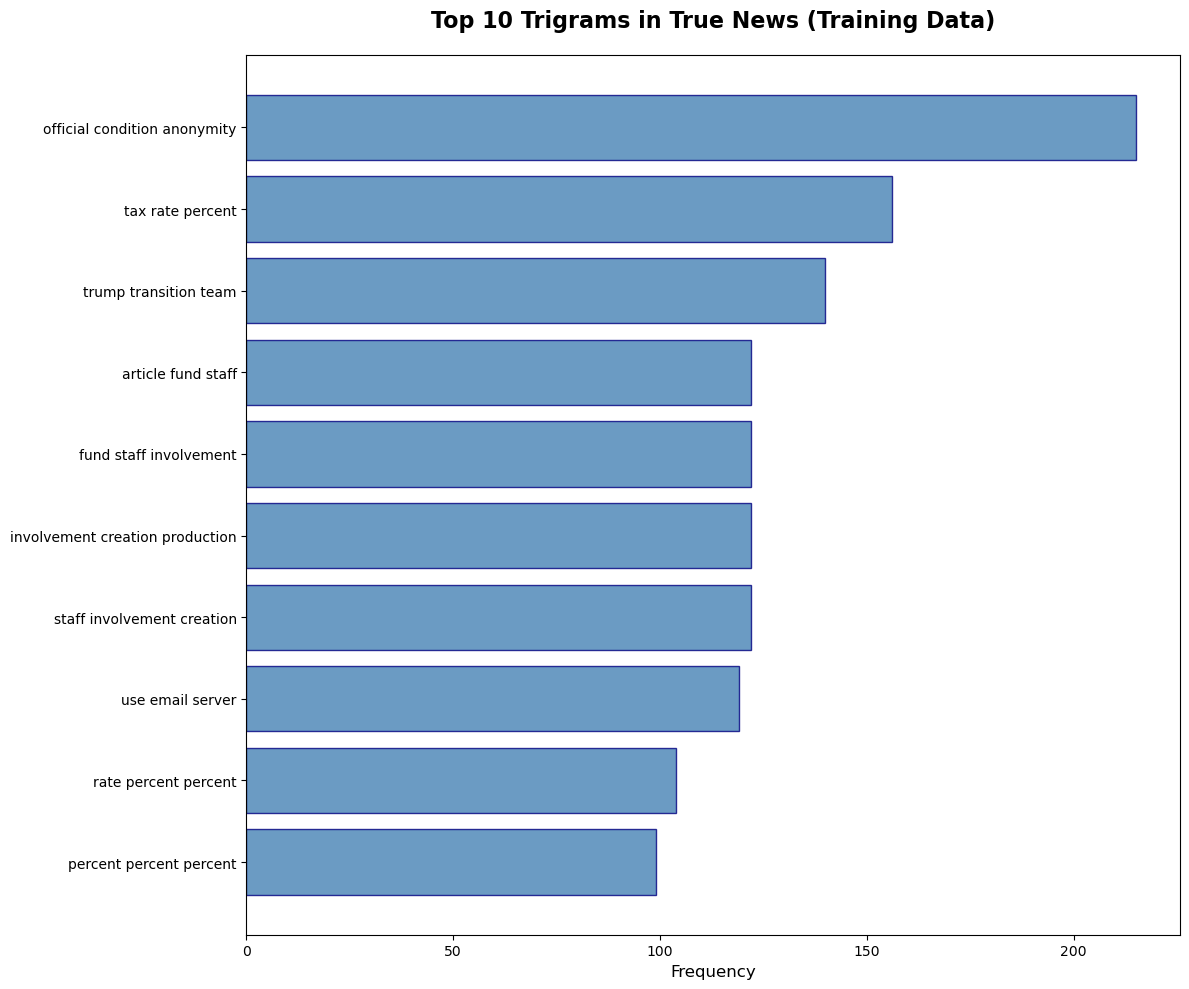

In [165]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
true_unigrams = get_top_ngrams(true_news_text, n=3, top_k=10)

plt.figure(figsize=(12, 10))

ngrams, frequencies = zip(*true_unigrams)

bars = plt.barh(range(len(ngrams)), frequencies, 
                   color='steelblue', edgecolor='navy', alpha=0.8)
    
plt.yticks(range(len(ngrams)), ngrams, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Trigrams in True News (Training Data)', 
            fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

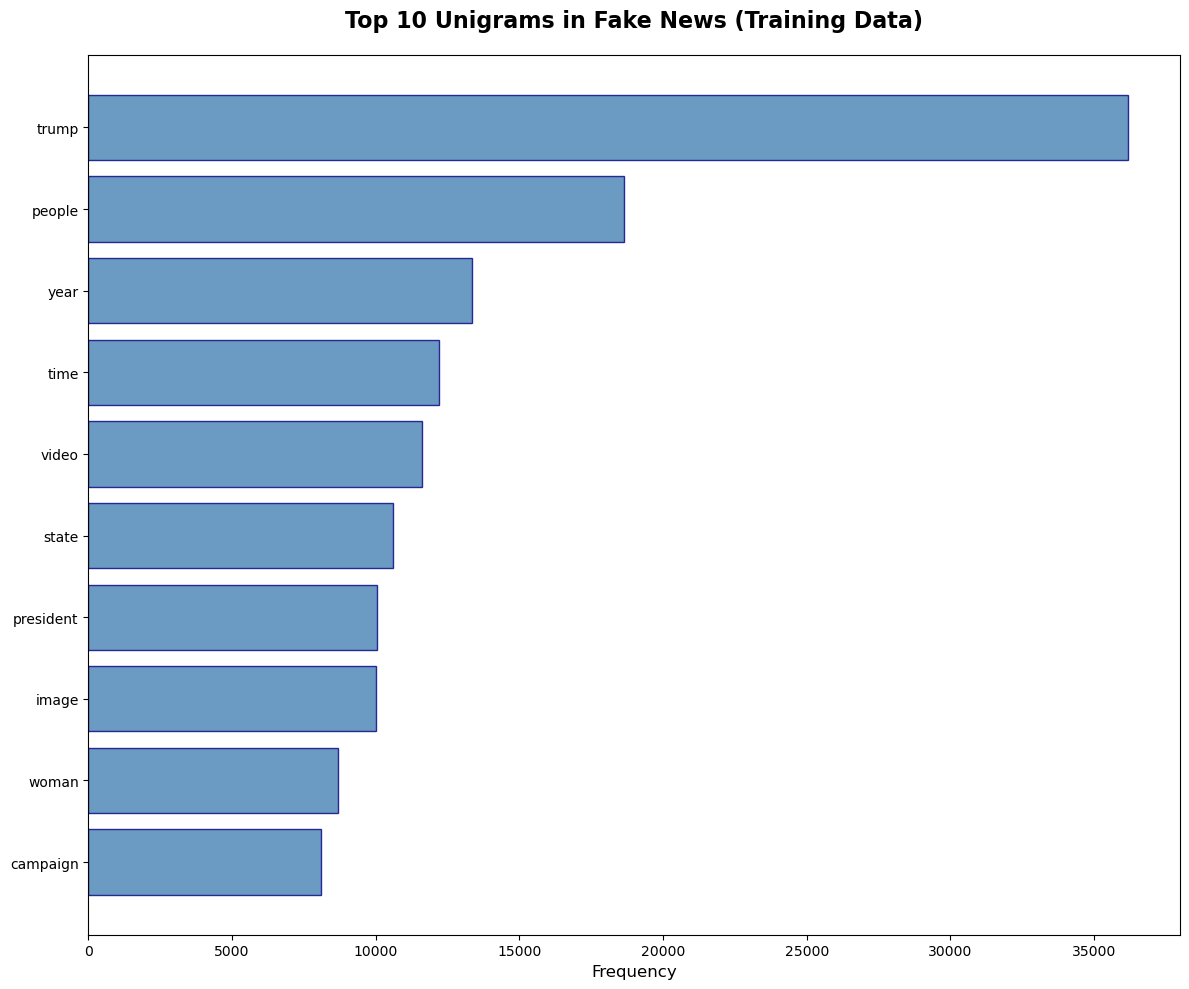

In [166]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
fake_unigrams = get_top_ngrams(fake_news_text, n=1, top_k=10)

plt.figure(figsize=(12, 10))

ngrams, frequencies = zip(*fake_unigrams)

bars = plt.barh(range(len(ngrams)), frequencies, 
                   color='steelblue', edgecolor='navy', alpha=0.8)
    
plt.yticks(range(len(ngrams)), ngrams, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Unigrams in Fake News (Training Data)', 
            fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



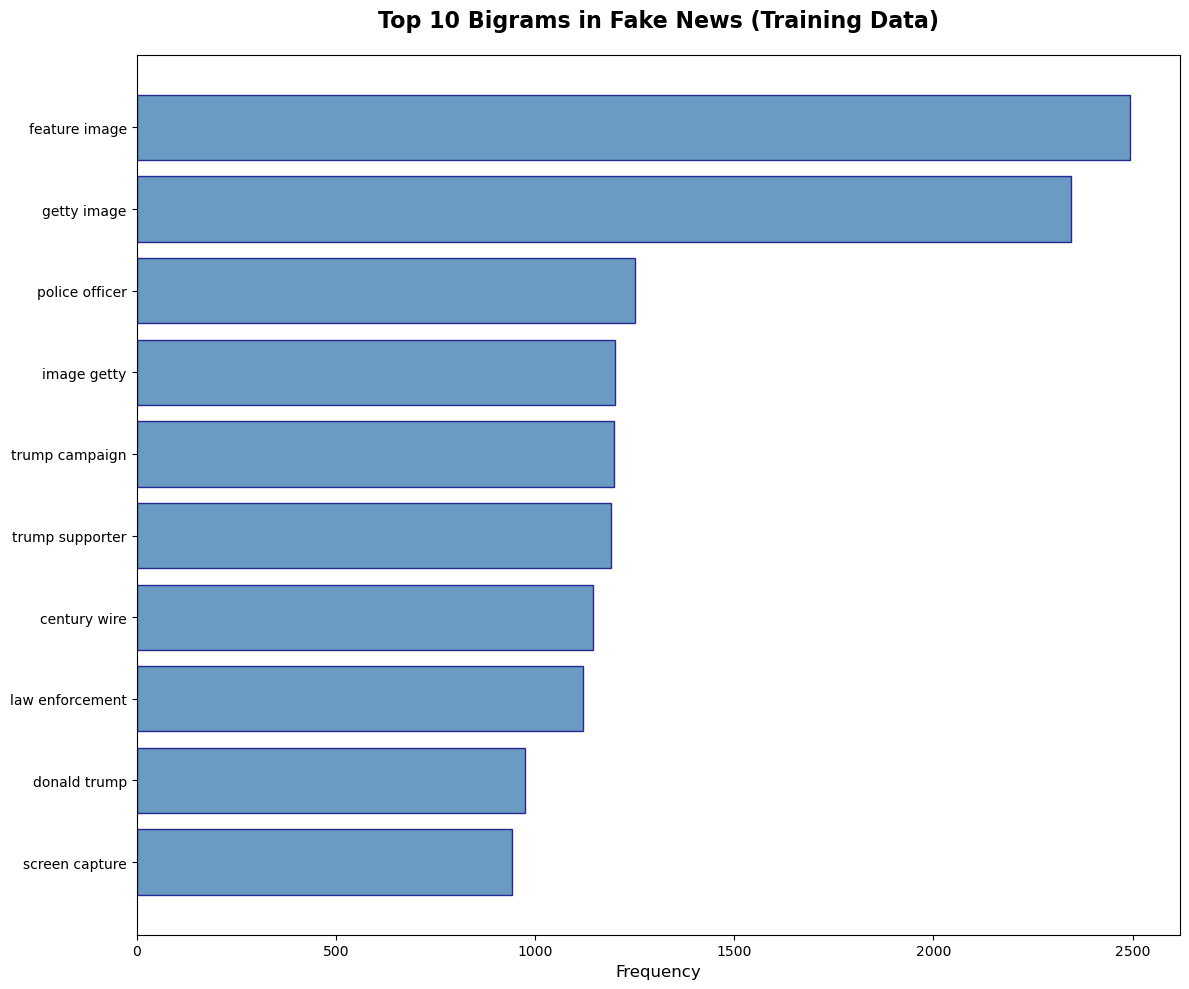

In [168]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
fake_unigrams = get_top_ngrams(fake_news_text, n=2, top_k=10)

plt.figure(figsize=(12, 10))

ngrams, frequencies = zip(*fake_unigrams)

bars = plt.barh(range(len(ngrams)), frequencies, 
                   color='steelblue', edgecolor='navy', alpha=0.8)
    
plt.yticks(range(len(ngrams)), ngrams, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Bigrams in Fake News (Training Data)', 
            fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



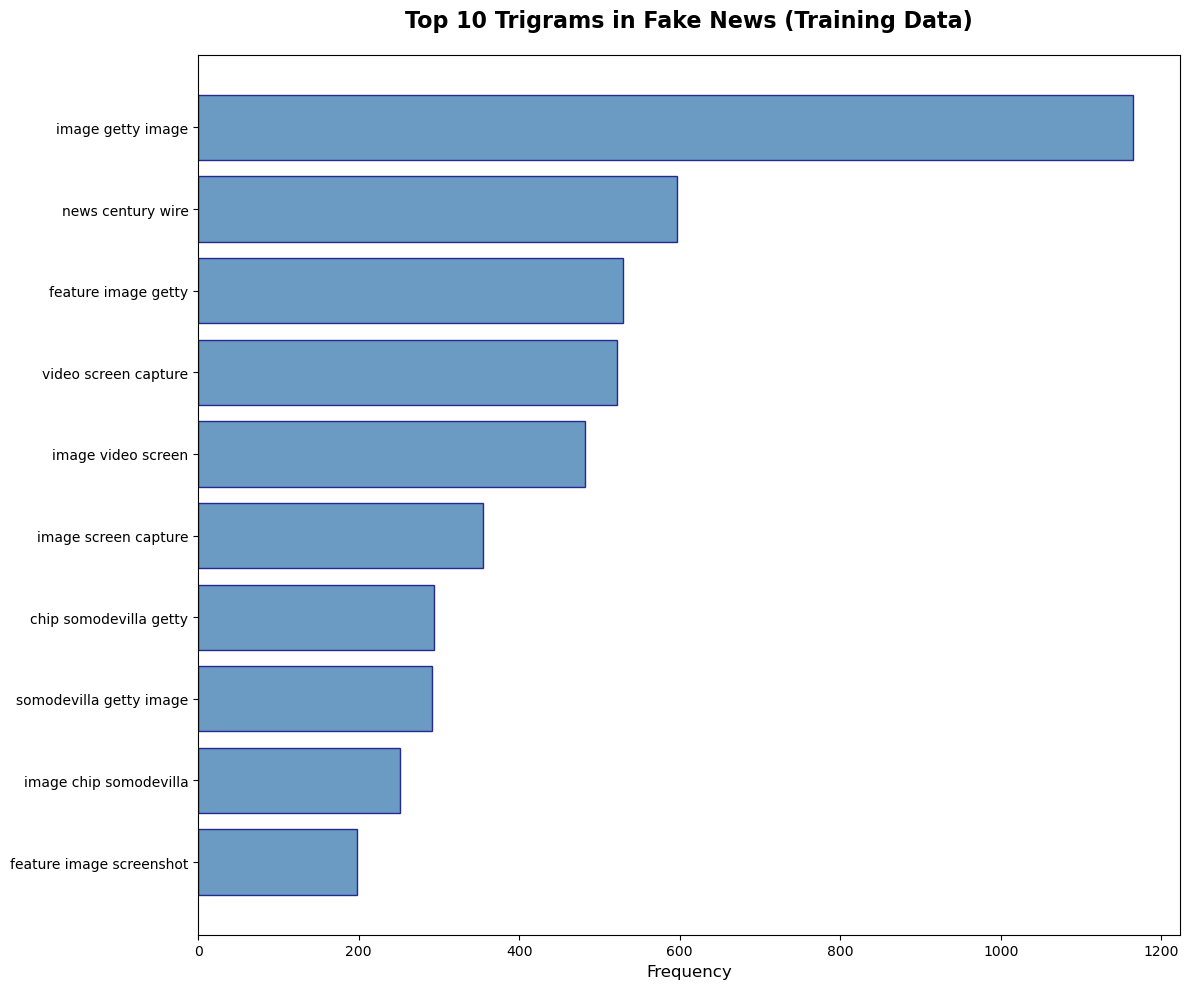

In [169]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
fake_unigrams = get_top_ngrams(fake_news_text, n=3, top_k=10)

plt.figure(figsize=(12, 10))

ngrams, frequencies = zip(*fake_unigrams)

bars = plt.barh(range(len(ngrams)), frequencies, 
                   color='steelblue', edgecolor='navy', alpha=0.8)
    
plt.yticks(range(len(ngrams)), ngrams, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Trigrams in Fake News (Training Data)', 
            fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [115]:
# Add a new column to calculate the character length of cleaned news text

# Add a new column to calculate the character length of lemmatized news text with POS tags removed


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [116]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

In [117]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text

# Generate word cloud for True News


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

In [118]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [119]:
## Write a function to get the specified top n-grams


##### 5.3.2 Handle the NaN values

In [120]:
## First handle NaN values in the text data


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

In [121]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

In [122]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

In [123]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

In [124]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

In [125]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

In [126]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph


## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [170]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
import gensim.downloader as api
from sklearn.feature_extraction.text import TfidfVectorizer

# Download and load the pre-trained Word2Vec model
w2v_model = api.load("word2vec-google-news-300")

print("Word2Vec model loaded successfully!")
print(f"Model vocabulary size: {len(w2v_model.key_to_index)}")
print(f"Vector dimensions: {w2v_model.vector_size}")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model loaded successfully!
Model vocabulary size: 3000000
Vector dimensions: 300


### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [171]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data

def get_word2vec_embeddings(texts, model, vector_size=300):
    embeddings = []
    
    for text in texts:
        if pd.isna(text) or text == '':
            # Handle empty/null text with zero vector
            embeddings.append(np.zeros(vector_size))
            continue
            
        # Split text into words
        words = str(text).split()
        
        # Get vectors for words that exist in vocabulary
        word_vectors = []
        for word in words:
            if word in model.key_to_index:
                word_vectors.append(model[word])
        
        if word_vectors:
            # Average the word vectors to get document embedding
            doc_embedding = np.mean(word_vectors, axis=0)
        else:
            # If no words found in vocabulary, use zero vector
            doc_embedding = np.zeros(vector_size)
            
        embeddings.append(doc_embedding)
    
    return np.array(embeddings)

# Extract vectors from Word2Vec model for training data

print("Extracting Word2Vec embeddings for training data...")
X_train_w2v = get_word2vec_embeddings(X_train, w2v_model)

print("Extracting Word2Vec embeddings for validation data...")
X_val_w2v = get_word2vec_embeddings(X_val, w2v_model)

print(f"Training embeddings shape: {X_train_w2v.shape}")
print(f"Validation embeddings shape: {X_val_w2v.shape}")

## Extract the target variable for the training data and validation data
y_train_target = y_train.values  # Convert to numpy array if needed
y_val_target = y_val.values      # Convert to numpy array if needed

print("Target variables extracted:")
print(f"Training target shape: {y_train_target.shape}")
print(f"Validation target shape: {y_val_target.shape}")


Extracting Word2Vec embeddings for training data...
Extracting Word2Vec embeddings for validation data...
Training embeddings shape: (31420, 300)
Validation embeddings shape: (13466, 300)
Target variables extracted:
Training target shape: (31420,)
Validation target shape: (13466,)


## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [208]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [209]:
## Initialise Logistic Regression model

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,        # Increase iterations for convergence
    solver='liblinear',   # Good solver for binary classification
    C=1.0,               # Regularization strength
    class_weight='balanced'  # Handle class imbalance
)

## Train Logistic Regression model on training data
lr_model.fit(X_train_w2v, y_train_target)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [210]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels

# Get predictions
y_val_pred = lr_model.predict(X_val_w2v)

# Get prediction probabilities
y_val_pred_proba = lr_model.predict_proba(X_val_w2v)

#Calculate Accuracy
accuracy = accuracy_score(y_val_target, y_val_pred)
print(f"Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

#Calculate Precision
precision = precision_score(y_val_target, y_val_pred)
print(f"Validation Precision: {precision:.4f} ({precision*100:.2f}%)")

#Calculate Recall
recall = recall_score(y_val_target, y_val_pred)
print(f"Validation Recall: {recall:.4f} ({recall*100:.2f}%)")

#Calculate F1-Score
f1 = f1_score(y_val_target, y_val_pred)
print(f"Validation F1-Score: {f1:.4f} ({f1*100:.2f}%)")

#Calculate  AUC
auc_score_lr = roc_auc_score(y_val_target, y_val_pred_proba[:, 1])
print(f"Validation AUC: {auc_score_lr:.4f} ({auc_score_lr*100:.2f}%)")


Validation Accuracy: 0.9041 (90.41%)
Validation Precision: 0.8902 (89.02%)
Validation Recall: 0.9113 (91.13%)
Validation F1-Score: 0.9006 (90.06%)
Validation AUC: 0.9666 (96.66%)


In [211]:
# Classification Report

# Final model summary
print("="*40)
print("="*40)
print(f"\nLR Classification Report:")
print(classification_report(y_val_target, y_val_pred, 
                          target_names=['Fake News', 'True News']))



LR Classification Report:
              precision    recall  f1-score   support

   Fake News       0.92      0.90      0.91      7041
   True News       0.89      0.91      0.90      6425

    accuracy                           0.90     13466
   macro avg       0.90      0.90      0.90     13466
weighted avg       0.90      0.90      0.90     13466



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [212]:
## Initialise Decision Tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,           # Prevent overfitting
    min_samples_split=20,   # Minimum samples to split a node
    min_samples_leaf=10,    # Minimum samples in leaf node
    max_features='sqrt',    # Number of features to consider for best split
    class_weight='balanced', # Handle class imbalance
    criterion='gini'        # Split criterion
)

## Train Decision Tree model on training data
dt_model.fit(X_train_w2v, y_train_target)

## Predict on validation data
y_val_pred_dt = dt_model.predict(X_val_w2v)

y_val_pred_proba_dt = dt_model.predict_proba(X_val_w2v)

print("Predictions completed!")
print(f"Validation predictions shape: {y_val_pred_dt.shape}")
print(f"Prediction probabilities shape: {y_val_pred_proba_dt.shape}")

# Display sample predictions
print(f"\nSample predictions (first 10):")
print(f"Actual:    {y_val_target[:10]}")
print(f"Predicted: {y_val_pred_dt[:10]}")

Predictions completed!
Validation predictions shape: (13466,)
Prediction probabilities shape: (13466, 2)

Sample predictions (first 10):
Actual:    [1 0 0 1 1 1 0 1 0 1]
Predicted: [0 0 0 0 1 1 1 1 1 1]


##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [219]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels

accuracy_dt = accuracy_score(y_val_target, y_val_pred_dt)
precision_dt = precision_score(y_val_target, y_val_pred_dt)
recall_dt = recall_score(y_val_target, y_val_pred_dt)
f1_dt = f1_score(y_val_target, y_val_pred_dt)
auc_score_dt = roc_auc_score(y_val_target, y_val_pred_proba_dt[:, 1])
print(f"\nDetailed Metrics:")

print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"AUC-ROC: {auc_score_rf:.4f}")


Detailed Metrics:
Precision: 0.7956
Recall: 0.7949
F1-Score: 0.7952
AUC-ROC: 0.9644


In [220]:
# Classification Report

print("="*40)
print("DECISION TREE MODEL EVALUATION RESULTS")
print("="*40)
print(f"\nClassification Report:")
print(classification_report(y_val_target, y_val_pred_dt, 
                          target_names=['Fake News', 'True News']))



DECISION TREE MODEL EVALUATION RESULTS

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.81      0.81      0.81      7041
   True News       0.80      0.79      0.80      6425

    accuracy                           0.80     13466
   macro avg       0.80      0.80      0.80     13466
weighted avg       0.80      0.80      0.80     13466



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [221]:
## Initialise Random Forest model

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model with optimized parameters
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees in the forest
    random_state=42,
    max_depth=15,          # Maximum depth of trees
    min_samples_split=10,   # Minimum samples to split a node
    min_samples_leaf=5,     # Minimum samples in leaf node
    max_features='sqrt',    # Number of features to consider for best split
    class_weight='balanced', # Handle class imbalance
    bootstrap=True,         # Use bootstrap sampling
    oob_score=True,        # Calculate out-of-bag score
    n_jobs=-1              # Use all available processors
)


## Train Random Forest model on training data
rf_model.fit(X_train_w2v, y_train_target)

## Predict on validation data
y_val_pred_rf = rf_model.predict(X_val_w2v)

# Get prediction probabilities
y_val_pred_proba_rf = rf_model.predict_proba(X_val_w2v)

print("Predictions completed!")
print(f"Validation predictions shape: {y_val_pred_rf.shape}")
print(f"Prediction probabilities shape: {y_val_pred_proba_rf.shape}")


Predictions completed!
Validation predictions shape: (13466,)
Prediction probabilities shape: (13466, 2)


 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [222]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Calculate accuracy
accuracy_rf = accuracy_score(y_val_target, y_val_pred_rf)
precision_rf = precision_score(y_val_target, y_val_pred_rf)
recall_rf = recall_score(y_val_target, y_val_pred_rf)
f1_rf = f1_score(y_val_target, y_val_pred_rf)
auc_score_rf = roc_auc_score(y_val_target, y_val_pred_proba_rf[:, 1])

print("Accuracy: ", accuracy_rf)
print("Precision: ", precision_rf)
print("Recall: ", recall_rf)
print("F1 Score: ", f1_rf)
print("AUC Score: ", auc_score_rf)


Accuracy:  0.901529778701916
Precision:  0.8979241454658967
Recall:  0.895408560311284
F1 Score:  0.8966645885286783
AUC Score:  0.9643617124159385


In [223]:
# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_val_target, y_val_pred_rf, 
                          target_names=['Fake News', 'True News']))



Classification Report:
              precision    recall  f1-score   support

   Fake News       0.90      0.91      0.91      7041
   True News       0.90      0.90      0.90      6425

    accuracy                           0.90     13466
   macro avg       0.90      0.90      0.90     13466
weighted avg       0.90      0.90      0.90     13466



## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE vs RANDOM FOREST
      Metric  Logistic Regression  Decision Tree  Random Forest
0   Accuracy               0.9041         0.8047         0.9015
1  Precision               0.8902         0.7956         0.8979
2     Recall               0.9113         0.7949         0.8954
3   F1-Score               0.9006         0.7952         0.8967
4  AUC Score               0.9666         0.8751         0.9644

Best performing model for each metric:
  Accuracy: Logistic Regression (0.9041)
  Precision: Random Forest (0.8979)
  Recall: Logistic Regression (0.9113)
  F1-Score: Logistic Regression (0.9006)
  AUC Score: Logistic Regression (0.9666)


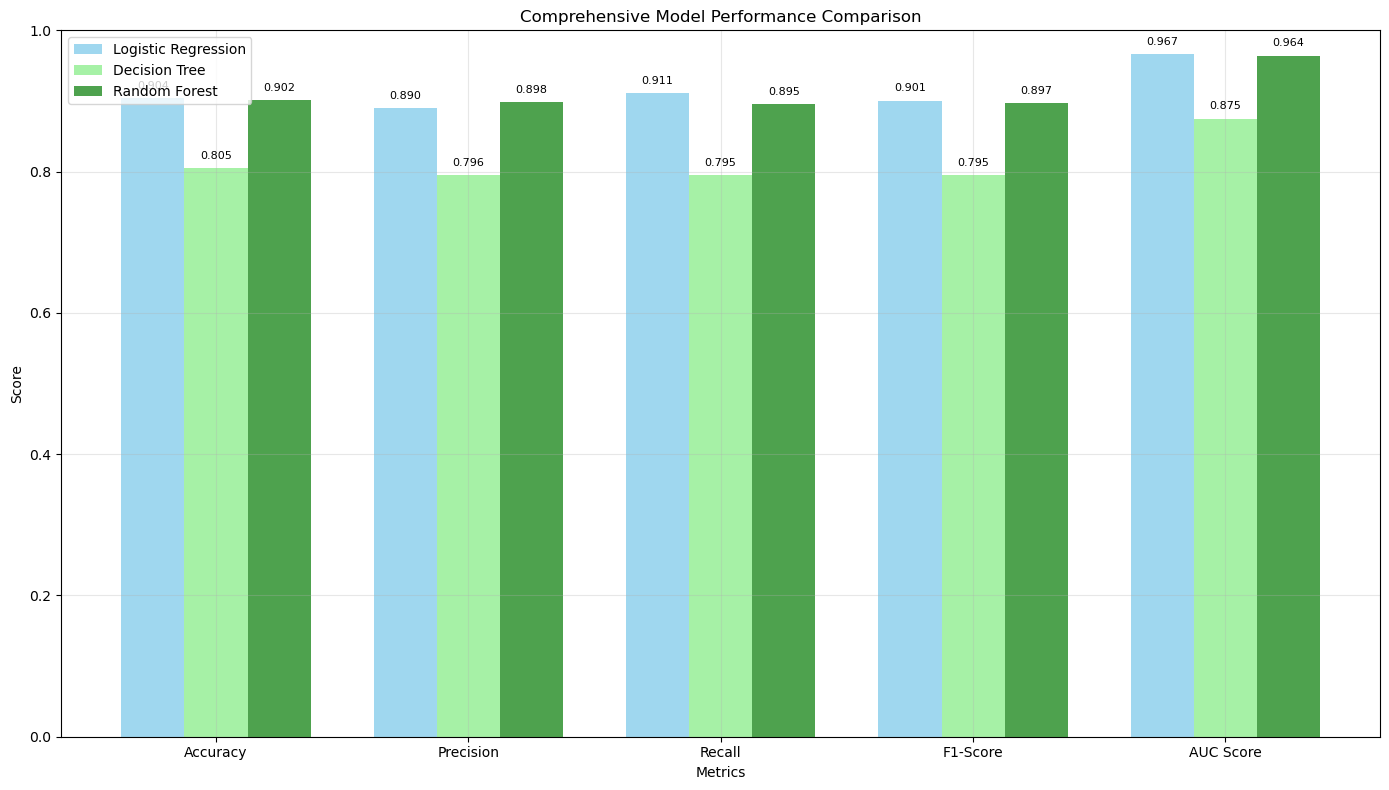

In [224]:
# Compare all three models
print("="*70)
print("MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE vs RANDOM FOREST")
print("="*70)

# Create comprehensive comparison DataFrame
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score','AUC Score'],
    'Logistic Regression': [accuracy, precision, recall, f1, auc_score_lr],
    'Decision Tree': [accuracy_dt, precision_dt, recall_dt, f1_dt, auc_score_dt],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf, auc_score_rf]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4))

# Find best model for each metric
print(f"\nBest performing model for each metric:")
for metric in comparison_data['Metric']:
    row = comparison_df[comparison_df['Metric'] == metric].iloc[0]
    best_model = row[1:].idxmax()
    best_score = row[1:].max()
    print(f"  {metric}: {best_model} ({best_score:.4f})")

# Visualization of comparison
plt.figure(figsize=(14, 8))
x = np.arange(len(comparison_data['Metric']))
width = 0.25

plt.bar(x - width, comparison_data['Logistic Regression'], width, 
        label='Logistic Regression', color='skyblue', alpha=0.8)
plt.bar(x, comparison_data['Decision Tree'], width, 
        label='Decision Tree', color='lightgreen', alpha=0.8)
plt.bar(x + width, comparison_data['Random Forest'], width, 
        label='Random Forest', color='forestgreen', alpha=0.8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Comprehensive Model Performance Comparison')
plt.xticks(x, comparison_data['Metric'])
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Add value labels
for i, (lr_val, dt_val, rf_val) in enumerate(zip(comparison_data['Logistic Regression'], 
                                                 comparison_data['Decision Tree'],
                                                 comparison_data['Random Forest'])):
    plt.text(i - width, lr_val + 0.01, f'{lr_val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i, dt_val + 0.01, f'{dt_val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + width, rf_val + 0.01, f'{rf_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()